In [151]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [152]:
import os
from pathlib import Path
repo_root = Path.cwd()
if not (repo_root / "model").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)


In [153]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.ReLaFIS import ReLaFIS, SklearnReLaFISWrapper
import torch
import torch.optim as optim


In [154]:
# config

import random

def set_random_state(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
# Generate a fresh seed per notebook run; it is recorded in learning_params below.
random_state = random.SystemRandom().randrange(0, 2**32)
set_random_state(random_state)

lr = 0.005
epochs = 100

lambda_rec_initial = 1.0
lambda_rec_floor = 0.01
# This epoch-based schedule is the notebook implementation; the paper does not specify its numeric formula.
# Use "fixed" and set lambda_rec_initial to the requested value for sensitivity experiments.
lambda_schedule = "decay"

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       epochs=epochs,
                       lambda_rec_initial=lambda_rec_initial,
                       lambda_rec_floor=lambda_rec_floor,
                       lambda_schedule=lambda_schedule)


In [155]:
# datasetdec

from tests.tabular_small import (
    Cryotheraphy, Haberman, Heart, Glass, SegmentaitionUCI, Wine, Thyroid,
    Immunotherapy, Iris, BreastCancer, PimaDiabetes, CarEvaluation, Autism,
    Digits, DNA, MFeat, Parkinson, SyntheticGaussian, PimaDiabetesCase2,
    DigitsUCI as Digits_UCI, BCW,
)
from tests.tabular_large import AdultIncome, BankMarketing, Smoke
from tests.bio_medical import Diabetes, Colon, Leukemia, SRBCT, Madelon, ORL, Isolet
from tests.image import MNIST, FashionMNIST
from tests.uci_thresholded import (
    EnergyEfficiencyHeating, EnergyEfficiencyCooling, Airfoil, Concrete,
    ConcreteMulticlass, CCPP,
)
from tests.inequality import (
    LinearThreshold, ExponentialGrowth, LogisticGrowth, DampedOscillator, PDE,
)
from torch.utils.data import DataLoader, TensorDataset


# Wine is retained as a smoke-test example. For paper reproduction, select the
# paper dataset here and set RULES to that experiment's specified rule count.
DATASET_CLASS = Haberman
DATASET_NAME = DATASET_CLASS.__name__
RULES = 2
experiment = DATASET_CLASS(session_id=random_state)

train_X, train_y = experiment.train_numpy()
if train_y.ndim == 2:
    train_y = np.argmax(train_y, axis=1)
else:
    train_y = np.asarray(train_y).reshape(-1)
classes = np.unique(train_y)
expected = np.arange(len(classes))
if not np.array_equal(classes, expected):
    raise ValueError(
        f"CrossEntropyLoss requires contiguous labels 0..C-1; got {classes}"
    )
train_dataset = TensorDataset(
    torch.as_tensor(train_X, dtype=torch.float32, device=device),
    torch.as_tensor(train_y, dtype=torch.long, device=device),
)

learning_params['dataset_name'] = DATASET_NAME
learning_params['rules'] = RULES
learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
regression = False


True

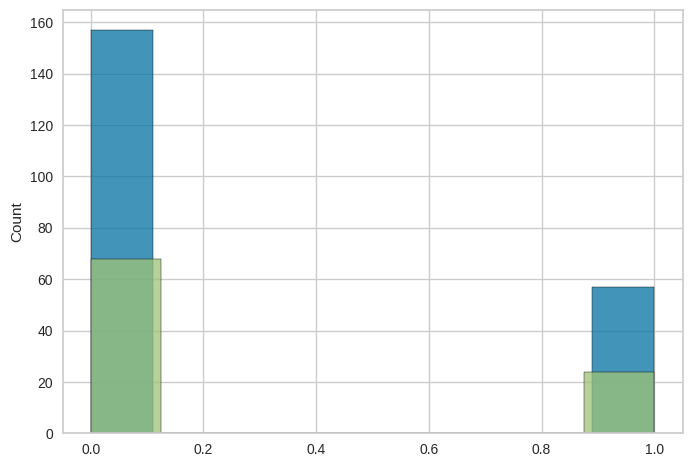

In [156]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(classes) == 2
binary


In [157]:
# prepare ReLaFIS

from model.ReLaFIS import ReLaFIS, SklearnReLaFISWrapper

model_params = {
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(classes),
    'rules': RULES,
    'drop_out_p': 0.3,
    'binary': binary,
    'zeta1': 1.0,
    'zeta2': 1.0,
    'zeta3': 1.0,
    'aggregation': 'product',
}

# Reinitialize the RNG immediately before model construction for reproducible paired runs.
set_random_state(random_state)
model = ReLaFIS(**model_params, dtype=torch.float32).to(device)
sk_model = SklearnReLaFISWrapper(model, device=device, dtype=torch.float32)

optimizer = optim.Adam(model.parameters(), lr=lr)
train_generator = torch.Generator().manual_seed(random_state)
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, generator=train_generator
)
classification_criterion = nn.CrossEntropyLoss()

# Exact sample-wise squared L2 reconstruction loss from Eq. (31).
def reconstruction_loss(reconstructed, X):
    return (reconstructed - X).pow(2).sum(dim=1).mean()

if lambda_schedule == "fixed":
    lambda_rec_floor = lambda_rec_initial
    lambda_decay = 1.0
else:
    decay_epochs = max(1, epochs // 2)
    if lambda_rec_initial <= 0:
        lambda_decay = 1.0
    else:
        lambda_decay = (lambda_rec_floor / lambda_rec_initial) ** (1.0 / decay_epochs)
lambda_rec = lambda_rec_initial


In [158]:
# Train for the predetermined epoch count. The fixed train/test protocol has no validation set;
# test data is not used for stopping, checkpoint selection, or training decisions.

history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_classification_loss = 0.0
    train_reconstruction_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device=device, dtype=torch.float32)
        batch_y = batch_y.to(device=device, dtype=torch.long)
        optimizer.zero_grad()
        logits, reconstructed = model(batch_X)
        classification_loss = classification_criterion(logits, batch_y)
        rec_loss = reconstruction_loss(reconstructed, batch_X)
        loss = classification_loss + lambda_rec * rec_loss
        loss.backward()
        optimizer.step()
        n = batch_X.size(0)
        train_loss += loss.item() * n
        train_classification_loss += classification_loss.item() * n
        train_reconstruction_loss += rec_loss.item() * n

    n_train = len(train_loader.dataset)
    train_loss /= n_train
    train_classification_loss /= n_train
    train_reconstruction_loss /= n_train
    print(f"Epoch {epoch + 1:3d} | Train Loss: {train_loss:.4f} | "
          f"CE: {train_classification_loss:.4f} | Rec: {train_reconstruction_loss:.4f} | "
          f"lambda_rec: {lambda_rec:.6g}")

    if lambda_schedule == "decay":
        lambda_rec = max(lambda_rec_floor, lambda_rec * lambda_decay)

print("Training complete; the held-out test set is evaluated in the next cell.")


Epoch   1 | Train Loss: 4.4645 | CE: 0.6858 | Rec: 3.7787 | lambda_rec: 1
Epoch   2 | Train Loss: 3.9965 | CE: 0.6674 | Rec: 3.6503 | lambda_rec: 0.912011
Epoch   3 | Train Loss: 3.5582 | CE: 0.6490 | Rec: 3.4976 | lambda_rec: 0.831764
Epoch   4 | Train Loss: 3.2081 | CE: 0.6295 | Rec: 3.3993 | lambda_rec: 0.758578
Epoch   5 | Train Loss: 2.8826 | CE: 0.6191 | Rec: 3.2717 | lambda_rec: 0.691831
Epoch   6 | Train Loss: 2.6442 | CE: 0.6120 | Rec: 3.2209 | lambda_rec: 0.630957
Epoch   7 | Train Loss: 2.4076 | CE: 0.5982 | Rec: 3.1443 | lambda_rec: 0.57544
Epoch   8 | Train Loss: 2.2289 | CE: 0.5935 | Rec: 3.1162 | lambda_rec: 0.524807
Epoch   9 | Train Loss: 2.0489 | CE: 0.5760 | Rec: 3.0774 | lambda_rec: 0.47863
Epoch  10 | Train Loss: 1.9312 | CE: 0.5689 | Rec: 3.1208 | lambda_rec: 0.436516
Epoch  11 | Train Loss: 1.8487 | CE: 0.5714 | Rec: 3.2082 | lambda_rec: 0.398107
Epoch  12 | Train Loss: 1.6699 | CE: 0.5587 | Rec: 3.0607 | lambda_rec: 0.363078
Epoch  13 | Train Loss: 1.5990 | CE: 

In [159]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters

from sklearn.metrics import classification_report, roc_auc_score
import pprint
import numpy as np

# Get raw labels (might be 1D or one‑hot)
y_train_raw = experiment.train_numpy()[1]
y_test_raw  = experiment.test_numpy()[1]

# Convert to 1D if necessary
if y_train_raw.ndim == 2:
    y_train = np.argmax(y_train_raw, axis=1)
    y_test  = np.argmax(y_test_raw, axis=1)
else:
    y_train = y_train_raw
    y_test  = y_test_raw

# Test evaluation begins only after training is complete.
model.eval()

# Get predicted probabilities
with torch.no_grad():
    y_train_proba = sk_model.predict_proba(experiment.train_numpy()[0])
    y_test_proba  = sk_model.predict_proba(experiment.test_numpy()[0])
    y_train_pred = sk_model.predict(experiment.train_numpy()[0])
    y_test_pred = sk_model.predict(experiment.test_numpy()[0])

# For binary classification, roc_auc_score expects probability of the positive class
if binary:
    # If probabilities have 2 columns, take the second column (positive class)
    if y_train_proba.shape[1] == 2:
        y_train_proba_bin = y_train_proba[:, 1]
        y_test_proba_bin  = y_test_proba[:, 1]
    else:
        y_train_proba_bin = y_train_proba[:, 0]
        y_test_proba_bin  = y_test_proba[:, 0]
    train_auc = roc_auc_score(y_train, y_train_proba_bin)
    test_auc  = roc_auc_score(y_test,  y_test_proba_bin)
else:
    # For multiclass, check if we have enough classes in both train and test sets
    train_classes = len(np.unique(y_train))
    test_classes = len(np.unique(y_test))
    
    if train_classes > 1 and test_classes > 1:
        try:
            train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
            test_auc  = roc_auc_score(y_test,  y_test_proba, multi_class='ovr')
        except ValueError:
            train_auc = float('nan')
            test_auc  = float('nan')
            print("Warning: Could not compute ROC AUC (insufficient classes)")
    else:
        train_auc = float('nan')
        test_auc  = float('nan')
        print(f"Warning: Insufficient classes for ROC AUC - Train: {train_classes}, Test: {test_classes}")

# Build result string
result = ""
result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(y_train, y_train_pred, digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(y_test, y_test_pred, digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)


Experiment Result Haberman
------ train ------
              precision    recall  f1-score   support

           0     0.7614    0.9554    0.8475       157
           1     0.5882    0.1754    0.2703        57

    accuracy                         0.7477       214
   macro avg     0.6748    0.5654    0.5589       214
weighted avg     0.7153    0.7477    0.6937       214
AUC	0.687674600514024
------ test ------
              precision    recall  f1-score   support

           0     0.7831    0.9559    0.8609        68
           1     0.6667    0.2500    0.3636        24

    accuracy                         0.7717        92
   macro avg     0.7249    0.6029    0.6123        92
weighted avg     0.7528    0.7717    0.7312        92
AUC	0.7288602941176471
{'aggregation': 'product',
 'binary': True,
 'drop_out_p': 0.3,
 'in_features': 3,
 'out_features': 2,
 'rules': 2,
 'zeta1': 1.0,
 'zeta2': 1.0,
 'zeta3': 1.0}
{'batch_size': 32,
 'dataset_name': 'Haberman',
 'epochs': 100,
 'lambda_rec

In [160]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance
'''import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()'''


'import numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import roc_curve, auc, RocCurveDisplay\nfrom sklearn.preprocessing import label_binarize\n\nX_test, y_test = experiment.test_numpy()\ny_score = sk_model.predict_proba(X_test)\n\nclasses = np.unique(y_test)\nn_classes = len(classes)\n\nplt.figure(figsize=(8, 8), dpi=200)\n\n# Binary classification\nif n_classes == 2:\n    # Determine which column(s) to use\n    if y_score.shape[1] == 2:\n        # Standard case: two columns, second is probability of positive class\n        y_score_bin = y_score[:, 1]\n    elif y_score.shape[1] == 1:\n        # Single column: assume it\'s probability of the positive class\n        y_score_bin = y_score[:, 0]\n    else:\n        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")\n\n    fpr, tpr, _ = roc_curve(y_test, y_score_bin)\n    roc_auc = auc(fpr, tpr)\n\n    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,\n                    estimator_name=\'Binary classifier